   # Business Understanding
#### Background
The background of this work is related to understanding the US health insurance context, reasons customers may or may not have insurance, which factors may or may not affect coverage, and ultimately how a company can effectively segregate their customers based on their characteristics.

#### Business objectives
Insurance companies have been responsible for assuring the safety and maintenance of people's health, goods and possessions while being capable off making a profit. 
The objective of this work is to create an automatized and efficient way of assisting in determining what type of customer should be granted an insurance, based on different characteristics they present. 

#### Business success criteria
With this work, the way to quantify success is through metrics such as prediction accuracy, AUC, recall. With this we mean that the success of the project depends on it´s capacity of predicting if a customer should have insurance.


## Assess Situation
#### Inventory of resources
The project is being developed by 3 people:
- Miguel Silva, 202105204, first year student of the Masters in Data Science;
- André Vieira, 202107341, first year student of the Masters in Data Science;
- Matheus Bissacot, , first year student of the Masters in Artificial Intelligence.

To develop the project, we were given two datasets. The first one, called customer.csv contains information about customers. The second one, called customer_test_masked.csv, contains a new dataset to be used as a test set and to evaluate the final performance of the models implemented.

About the technology used, we are using our personal laptops, which vary on their capabilities, but have a range of 16-32 gbs of RAM, 512GB-1TB of storage, and Intel I3-Intel I7 processors. Python 3.12 was used in the development of the project, as well as some libraries used in data manipulation, visualization, and modelling, such as:
- Seaborn;
- Matplotlib;
- Pandas;
- Numpy;

#### Risks and Contingencies
The main risk we expect based in a preliminary analysis of the dataset is a problem with the data quality, mainly because the customer.csv dataset may have missing values, incorrect entries or inconsistencies such as income data outliers or unknown values for certain demographics, for which we can implement data cleaning steps, such as filling missing values using median or mode imputation, or removing problematic records if feasible.

Another possible problem arises from the possibility of the dataset having some sort of bias, wich could lead the model to unfairly favor certain grops or demographics. An example of this is that if the dataset over-represents high-income individuals, the model may be biased towards predicting health insurance for everyone.
A possible contingency is to regularly assess model fairness across demographic groups, using techniques such as stratified sampling to ensure balanced representation, and consider post-processing adjustments if certain groups show higher prediction error rates.

## Determine Data Mining Goals

#### Data mining goals
Create a predictive model that accurately classifies customers as either insured or uninsured based on provided features while understanding feature importance to potentially identify key drivers influencing insurance status.

#### Data mining success criteria
The model should achieve a specific threshold of accuracy, precision, recall and F1-score. For example:
    Overall accuracy > 85%
    Recall for uninsured customers > 90% (as this group might be of particular interest for outreach or services)
The model should be interpretable enough to identify patterns that align with business strategies for customer engagement.



# Data Understanding

## Collect Initial Data

#### Initial Data Collection Report
The dataset was loaded and reviewed to understand its structure, data types, and any missing values. It includes client demographic and economic information, like custid (unique ID), is_employed (employment status), income, marital_status, housing_type, num_vehicles (number of vehicles), gas_usage, and recent_move_b (recent move indicator). These attributes help us get a picture of the clients and will be useful to predict their likelihood of buying health insurance (health_ins), which is our target variable.

## Describe Data

#### Data Description Report

Each variable was described, including data types (e.g., categorical, numerical), unique values, and ranges. We noticed that some columns had a significant amount of missing values, like is_employed (35.21% missing), housing_type, num_vehicles, and gas_usage. This report helped us understand each column’s characteristics and its relevance to the analysis.

## Explore Data

#### Data Exploration Report
Exploratory data analysis (EDA) was conducted to find patterns, outliers, and the distribution of values. Summary statistics, like mean, median, standard deviation, and variance, were calculated for numerical variables such as income, num_vehicles, and gas_usage. Visualizations, including pie charts and bar plots, were used to show the distribution of categorical variables like is_employed and recent_move_b. For example, a pie chart for is_employed showed the proportion of employed vs. unemployed clients, which helped us understand the demographic makeup of the dataset and decide how to handle missing values.

## Verify Data Quality

#### Data Quality Report
Quality checks were performed to ensure data reliability:

- Missing Value Analysis: Columns with missing values were identified, and specific strategies for filling them in were considered. For categorical variables with a clear majority (like is_employed, housing_type, and recent_move_b), we decided to fill missing values with the mode (most common value). For gas_usage, given its high variability, we used "Unknown" as a placeholder to avoid bias. For num_vehicles, which had low variance, the median was used to minimize the effect of any extreme values.

- Duplicate Check: The custid column was checked for uniqueness to confirm that each row represents a unique client.

- Outlier Detection: Although not explicitly stated, analyzing the range and variance of columns like income and num_vehicles helped identify potential outliers, which could be further addressed if needed.

# Data Preparation
## Select Data

#### Rationale for Inclusion/Exclusion
All columns were kept for analysis, as each was considered useful for predicting the target variable (health_ins). No columns were excluded since each attribute was thought to add valuable information to understand clients' behavior regarding health insurance.

## Clean Data:

#### Data Cleaning Report 
Missing values were addressed as follows:

- Categorical Columns: Missing values in is_employed, housing_type, and recent_move_b were filled with the mode, as these columns had a common category, helping us keep the data as accurate as possible.

- Numerical Columns: For num_vehicles, the median was used due to low variance, reducing the impact of outliers on the data.

- High-Variance Categorical Columns: In gas_usage, the category "Unknown" was added for missing cases, as the distribution was too varied to select a single dominant value.

## Construct Data:

#### Derived Attributes 
No new features were created in this phase. However, derived attributes like income_per_vehicle (income divided by number of vehicles) could be considered in future steps to enhance predictive power.

#### Generated Records 
No synthetic records were created; the original dataset was maintained, with values filled where necessary.

## Integrate Data

#### Merged Data
Since this analysis was conducted on a single dataset, no merging with other datasets was required. All necessary client data was included in the initial dataset.

## Format Data

#### Reformatted Data
The health_ins column, which is the target variable, was moved to the end of the DataFrame for better clarity. This reordering makes it easier to work with the dataset during the modeling process.

## Dataset

#### Dataset Description
The final dataset includes all the relevant variables, cleaned, filled, and organized, ready for predictive analysis on health insurance purchase. Each column has been checked for completeness and consistency, ensuring that the dataset is ready for the next stages of analysis and modeling.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\andre\Documents\Faculdade\Mestrado\1ano_1sem\ICD\trabalho\customer.csv")
df

,Unnamed: 0,custid,sex,is_employed,income,marital_status,health_ins,housing_type,num_vehicles,age,state_of_res,code_column,gas_usage,rooms,recent_move_b
0,7,000006646_03,Male,True,22000.0,Never married,True,Homeowner free and clear,0.0,24,Alabama,1047,210.0,3,F
1,8,000007827_01,Female,NaN,23200.0,Divorced/Separated,True,Rented,0.0,82,Alabama,1047,3.0,6,T
2,9,000008359_04,Female,True,21000.0,Never married,True,Homeowner with mortgage/loan,2.0,31,Alabama,1047,40.0,3,F
3,10,000008529_01,Female,NaN,37770.0,Widowed,True,Homeowner free and clear,1.0,93,Alabama,1047,120.0,2,F
4,11,000008744_02,Male,True,39000.0,Divorced/Separated,True,Rented,2.0,67,Alabama,1047,3.0,2,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72453,99996,001506841_02,Female,True,18500.0,Never married,False,Rented,1.0,25,Wyoming,131,10.0,4,F
72454,99997,001507219_01,Female,NaN,20800.0,Widowed,True,Homeowner free and clear,1.0,86,Wyoming,131,120.0,6,F
72455,99998,001513103_01,Male,True,75000.0,Married,True,Homeowner with mortgage/loan,2.0,50,Wyoming,131,90.0,3,F
72456,99999,001519624_01,Female,True,22200.0,Divorced/Separated,False,Homeowner free and clear,1.0,61,Wyoming,131,50.0,6,F


In [3]:
df = df.rename(columns={'Unnamed: 0': 'idx'})
df = df.set_index('idx')
df.reset_index(drop=True, inplace=True)
df

,custid,sex,is_employed,income,marital_status,health_ins,housing_type,num_vehicles,age,state_of_res,code_column,gas_usage,rooms,recent_move_b
0,000006646_03,Male,True,22000.0,Never married,True,Homeowner free and clear,0.0,24,Alabama,1047,210.0,3,F
1,000007827_01,Female,NaN,23200.0,Divorced/Separated,True,Rented,0.0,82,Alabama,1047,3.0,6,T
2,000008359_04,Female,True,21000.0,Never married,True,Homeowner with mortgage/loan,2.0,31,Alabama,1047,40.0,3,F
3,000008529_01,Female,NaN,37770.0,Widowed,True,Homeowner free and clear,1.0,93,Alabama,1047,120.0,2,F
4,000008744_02,Male,True,39000.0,Divorced/Separated,True,Rented,2.0,67,Alabama,1047,3.0,2,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72453,001506841_02,Female,True,18500.0,Never married,False,Rented,1.0,25,Wyoming,131,10.0,4,F
72454,001507219_01,Female,NaN,20800.0,Widowed,True,Homeowner free and clear,1.0,86,Wyoming,131,120.0,6,F
72455,001513103_01,Male,True,75000.0,Married,True,Homeowner with mortgage/loan,2.0,50,Wyoming,131,90.0,3,F
72456,001519624_01,Female,True,22200.0,Divorced/Separated,False,Homeowner free and clear,1.0,61,Wyoming,131,50.0,6,F


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72458 entries, 0 to 72457
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   custid          72458 non-null  object 
 1   sex             72458 non-null  object 
 2   is_employed     46943 non-null  object 
 3   income          72458 non-null  float64
 4   marital_status  72458 non-null  object 
 5   health_ins      72458 non-null  bool   
 6   housing_type    70772 non-null  object 
 7   num_vehicles    70772 non-null  float64
 8   age             72458 non-null  int64  
 9   state_of_res    72458 non-null  object 
 10  code_column     72458 non-null  int64  
 11  gas_usage       70772 non-null  float64
 12  rooms           72458 non-null  int64  
 13  recent_move_b   70771 non-null  object 
dtypes: bool(1), float64(3), int64(3), object(7)
memory usage: 7.3+ MB


In [5]:
df.isnull().sum()

custid                0
sex                   0
is_employed       25515
income                0
marital_status        0
health_ins            0
housing_type       1686
num_vehicles       1686
age                   0
state_of_res          0
code_column           0
gas_usage          1686
rooms                 0
recent_move_b      1687
dtype: int64

In [6]:
df.isnull().mean() * 100

custid             0.000000
sex                0.000000
is_employed       35.213503
income             0.000000
marital_status     0.000000
health_ins         0.000000
housing_type       2.326865
num_vehicles       2.326865
age                0.000000
state_of_res       0.000000
code_column        0.000000
gas_usage          2.326865
rooms              0.000000
recent_move_b      2.328245
dtype: float64

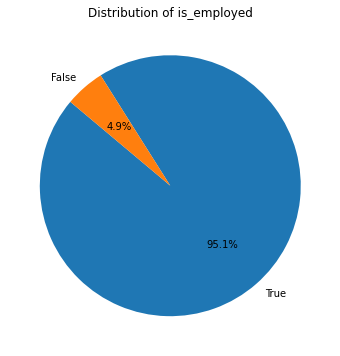

In [7]:
#Análise da distribuição de valores na coluna 'is_employed'

counts2 = df['is_employed'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(counts2, labels=counts2.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of is_employed')
plt.show()

Como para este caso específico, a categoria "True" é claramente a categoria dominante, decidimos substituir os valores ausentes por esta categoria que representa a moda dos dados.

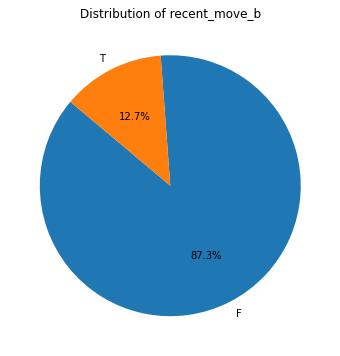

In [8]:
#Análise da distribuição de valores na coluna 'recent_move_b'

counts3 = df['recent_move_b'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(counts3, labels=counts3.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of recent_move_b')
plt.show()

Como para este caso específico, a categoria "F" é claramente a categoria dominante, decidimos substituir os valores ausentes por esta categoria que representa a moda dos dados.

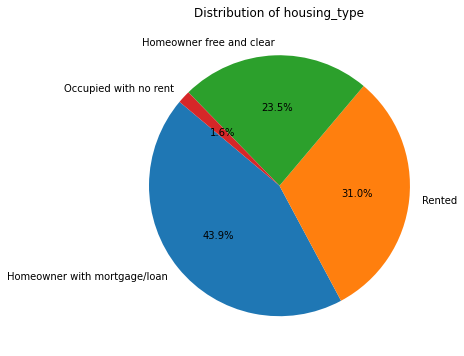

In [9]:
#Análise da distribuição de valores na coluna 'housing_type'

counts = df['housing_type'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of housing_type')
plt.show()

Como para este caso específico, a categoria "Homeowner with mortgage/loan" parece ser a categoria dominante, decidimos substituir os valores ausentes por esta categoria que representa a moda dos dados.

In [10]:
# Análise na distribuição de valores na coluna gas_usage

# 1. Amplitude (Range)
amplitude = df['gas_usage'].max() - df['gas_usage'].min()
print(f"Amplitude: {amplitude}")

# 2. Desvio padrão (Standard Deviation)
desvio_padrao = df['gas_usage'].std()
print(f"Desvio Padrão: {desvio_padrao}")

# 3. Variância (Variance)
variancia = df['gas_usage'].var()
print(f"Variância: {variancia}")

Amplitude: 569.0
Desvio Padrão: 63.14932331801959
Variância: 3987.837035523773


Como a amplitude, desvio padrão e variância são bastante elevados, decidi criar outro valor chamado unknown para manter a integridade das outras categorias.

In [11]:
# Análise na distribuição de valores na coluna num_vehicles

# 1. Amplitude (Range)
amplitude = df['num_vehicles'].max() - df['num_vehicles'].min()
print(f"Amplitude: {amplitude}")

# 2. Desvio padrão (Standard Deviation)
desvio_padrao = df['num_vehicles'].std()
print(f"Desvio Padrão: {desvio_padrao}")

# 3. Variância (Variance)
variancia = df['num_vehicles'].var()
print(f"Variância: {variancia}")

Amplitude: 6.0
Desvio Padrão: 1.1700759939435181
Variância: 1.3690778316029117


Como a amplitude, desvio padrão e variância são relativamente baixos, decidi preencher os valores nulos com a mediana já que não irá comprometer a integridade do resto dos dados.

In [12]:
df['is_employed'].fillna(df['is_employed'].mode()[0], inplace=True)

df['recent_move_b'].fillna(df['recent_move_b'].mode()[0], inplace=True)

df['housing_type'].fillna(df['housing_type'].mode()[0], inplace=True)

df['gas_usage'].fillna('Unknown', inplace=True)

df['num_vehicles'].fillna(df['num_vehicles'].median(), inplace=True)

C:\Users\andre\AppData\Local\Temp\ipykernel_14088\3888037455.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['is_employed'].fillna(df['is_employed'].mode()[0], inplace=True)
C:\Users\andre\AppData\Local\Temp\ipykernel_14088\3888037455.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_employed'].

In [13]:
df.isnull().sum()

custid            0
sex               0
is_employed       0
income            0
marital_status    0
health_ins        0
housing_type      0
num_vehicles      0
age               0
state_of_res      0
code_column       0
gas_usage         0
rooms             0
recent_move_b     0
dtype: int64

In [14]:
# 1. Remover a goal column e armazená-la temporariamente
goal = df.pop('health_ins')

# 2. Adicionar a coluna novamente ao final do DataFrame
df['health_ins'] = goal

df

,custid,sex,is_employed,income,marital_status,housing_type,num_vehicles,age,state_of_res,code_column,gas_usage,rooms,recent_move_b,health_ins
0,000006646_03,Male,True,22000.0,Never married,Homeowner free and clear,0.0,24,Alabama,1047,210.0,3,F,True
1,000007827_01,Female,True,23200.0,Divorced/Separated,Rented,0.0,82,Alabama,1047,3.0,6,T,True
2,000008359_04,Female,True,21000.0,Never married,Homeowner with mortgage/loan,2.0,31,Alabama,1047,40.0,3,F,True
3,000008529_01,Female,True,37770.0,Widowed,Homeowner free and clear,1.0,93,Alabama,1047,120.0,2,F,True
4,000008744_02,Male,True,39000.0,Divorced/Separated,Rented,2.0,67,Alabama,1047,3.0,2,F,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72453,001506841_02,Female,True,18500.0,Never married,Rented,1.0,25,Wyoming,131,10.0,4,F,False
72454,001507219_01,Female,True,20800.0,Widowed,Homeowner free and clear,1.0,86,Wyoming,131,120.0,6,F,True
72455,001513103_01,Male,True,75000.0,Married,Homeowner with mortgage/loan,2.0,50,Wyoming,131,90.0,3,F,True
72456,001519624_01,Female,True,22200.0,Divorced/Separated,Homeowner free and clear,1.0,61,Wyoming,131,50.0,6,F,False


In [15]:
unique_values = df['custid'].nunique()
print(unique_values)

72458


Como o nº de valores únicos da coluna 'custid' corresponde ao nº de linhas, então podemos admitir que não existem valores duplicados para ser tratados.

## Modelling

In [16]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [17]:
# Dividir variáveis preditoras e alvo
X = df.drop(columns=["health_ins"])  # 'health_ins' é a variável alvo
y = df["health_ins"]

In [18]:
# Divisão dos dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# Identificação de variáveis categóricas e numéricas
categorical_features = X.select_dtypes(include=["object", "category"]).columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

# Garantindo que as variáveis categóricas sejam strings
X_train[categorical_features] = X_train[categorical_features].astype(str)
X_test[categorical_features] = X_test[categorical_features].astype(str)

# Pipeline para pré-processamento de dados
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # Tratamento de valores ausentes com mediana
    ("scaler", StandardScaler())  # Normalização dos dados numéricos
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # Tratamento de valores ausentes com moda
    ("onehot", OneHotEncoder(handle_unknown="ignore"))  # One-hot encoding para variáveis categóricas
])

# Combinando pré-processadores numéricos e categóricos
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [20]:
# Lista dos primeiros modelos para treinamento
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(probability=True)
}

# Treinamento e avaliação dos modelos
results = {}
for model_name, model in models.items():
    # Pipeline para cada modelo
    clf = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
    
    # Treinamento do modelo
    clf.fit(X_train, y_train)
    
    # Previsões e métricas
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else None
    
    # Avaliação usando métricas de classificação
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else "N/A"
    
    # Armazenando os resultados
    results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    }


C:\Users\andre\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
import joblib

# Salvando os modelos treinados em arquivos
for model_name, model in models.items():
    joblib.dump(model, f"{model_name}_model.pkl")

In [22]:
# Criando um DataFrame para visualização
results_df = pd.DataFrame(results)
print(results_df)

           Logistic Regression  Decision Tree  Random Forest  \
Accuracy              0.903947       0.890077       0.905465   
Precision             0.905501       0.914894       0.906263   
Recall                0.997862       0.968468       0.998702   
F1 Score              0.949441       0.940919       0.950240   
ROC AUC               0.791613       0.560992       0.775294   

           Gradient Boosting  K-Nearest Neighbors  Support Vector Machine  
Accuracy            0.904430             0.893113                0.904292  
Precision           0.906673             0.910325                0.904525  
Recall              0.996870             0.978088                0.999618  
F1 Score            0.949635             0.942991                0.949697  
ROC AUC             0.819640             0.669793                0.775092  


In [23]:
import pandas as pd
import joblib

# Carregar o dataset de teste
customer_test = pd.read_csv(r'C:\Users\andre\Documents\Faculdade\Mestrado\1ano_1sem\ICD\trabalho\customer_test_masked.csv')

# Pré-processar os dados de teste (assumindo que o 'preprocessor' já está definido)
X_test_new = preprocessor.transform(customer_test)

print(f"Linhas no dataset de teste original: {len(customer_test)}")
print(f"Linhas após a transformação: {X_test_new.shape[0]}")

# Carregar o modelo principal e fazer previsões
final_model = joblib.load("Gradient Boosting_model.pkl")  # ou qualquer outro modelo salvo
final_predictions = final_model.predict(X_test_new)

# Criar o DataFrame para submissão usando a coluna 'custid'
submission_df = customer_test[['custid']].copy()  # Usar 'custid' como identificador do cliente
submission_df['health_ins'] = final_predictions  # Colocar as previsões no campo 'health_ins'

# Salvar as previsões em sample_submissions.csv
submission_df.to_csv('sample_submissions.csv', index=False)

Linhas no dataset de teste original: 804
Linhas após a transformação: 804


--- Logistic Regression ---


C:\Users\andre\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Decision Tree ---
--- Random Forest ---
--- Gradient Boosting ---
--- K-Nearest Neighbors ---
--- Support Vector Machine ---

Top Features for Logistic Regression:


,Feature,Importance
58062,cat__gas_usage_340.0,1.358799
0,num__income,1.264656
58089,cat__gas_usage_Unknown,1.251644
58078,cat__gas_usage_480.0,1.235228
58026,cat__state_of_res_Vermont,1.191238
58054,cat__gas_usage_280.0,1.087055
58079,cat__gas_usage_490.0,1.054512
58002,cat__state_of_res_Massachusetts,1.025701
58076,cat__gas_usage_460.0,1.019532
57992,cat__state_of_res_Hawaii,0.952422


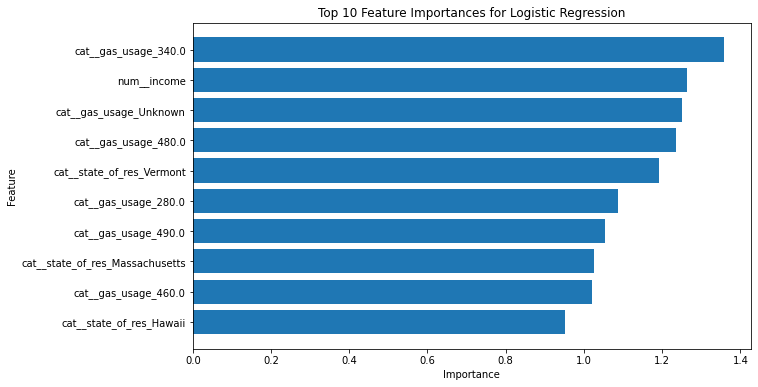


Top Features for Decision Tree:


,Feature,Importance
0,num__income,0.097998
2,num__age,0.084650
4,num__rooms,0.023866
3,num__code_column,0.019642
1,num__num_vehicles,0.018162
57974,cat__marital_status_Married,0.010709
57971,cat__sex_Female,0.009992
58024,cat__state_of_res_Texas,0.009725
58089,cat__gas_usage_Unknown,0.008926
57980,cat__housing_type_Rented,0.008714


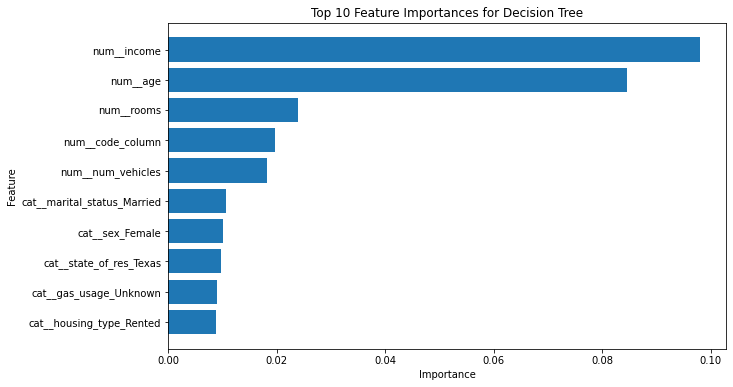


Top Features for Random Forest:


,Feature,Importance
0,num__income,0.079269
2,num__age,0.072057
4,num__rooms,0.037129
1,num__num_vehicles,0.030740
3,num__code_column,0.021423
57980,cat__housing_type_Rented,0.009738
57974,cat__marital_status_Married,0.009029
57975,cat__marital_status_Never married,0.008858
57978,cat__housing_type_Homeowner with mortgage/loan,0.007120
58056,cat__gas_usage_3.0,0.007116


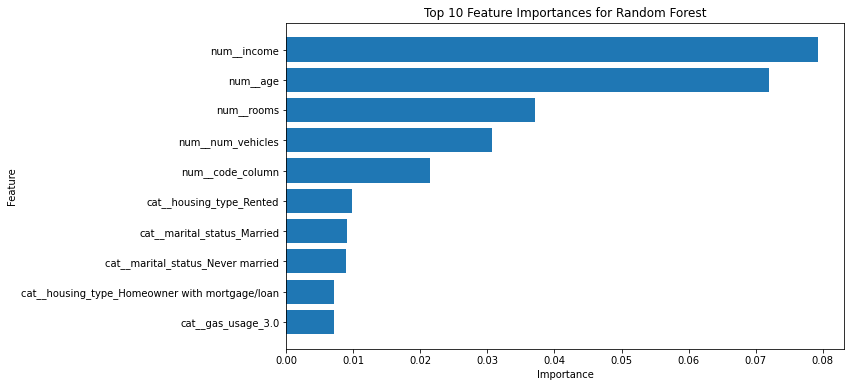


Top Features for Gradient Boosting:


,Feature,Importance
0,num__income,0.336516
2,num__age,0.287582
57980,cat__housing_type_Rented,0.058991
58089,cat__gas_usage_Unknown,0.050455
58024,cat__state_of_res_Texas,0.049313
57972,cat__sex_Male,0.039182
57974,cat__marital_status_Married,0.032196
57971,cat__sex_Female,0.025278
57978,cat__housing_type_Homeowner with mortgage/loan,0.023015
57990,cat__state_of_res_Florida,0.012004


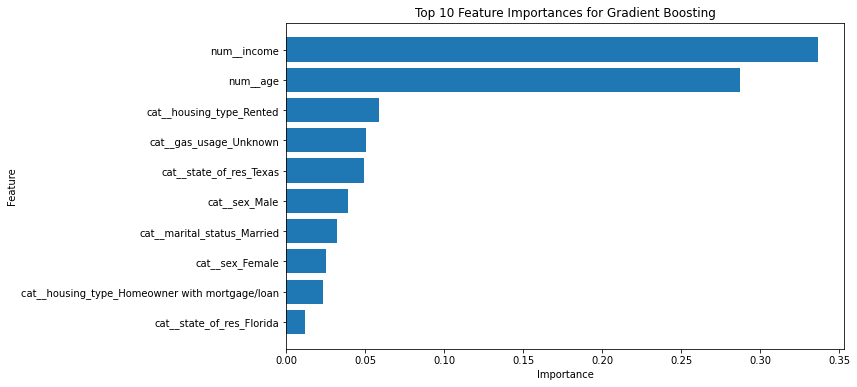


Top Features for K-Nearest Neighbors:


,Feature,Importance
7,cat__custid_000000036_02,0.003285
8,cat__custid_000000085_01,0.002802
9,cat__custid_000000118_02,0.001601
4,num__rooms,0.001325
3,num__code_column,0.001090
1,num__num_vehicles,0.000787
6,cat__custid_000000030_01,0.000276
0,num__income,0.000000
2,num__age,0.000000
10,cat__custid_000000154_03,-0.000097


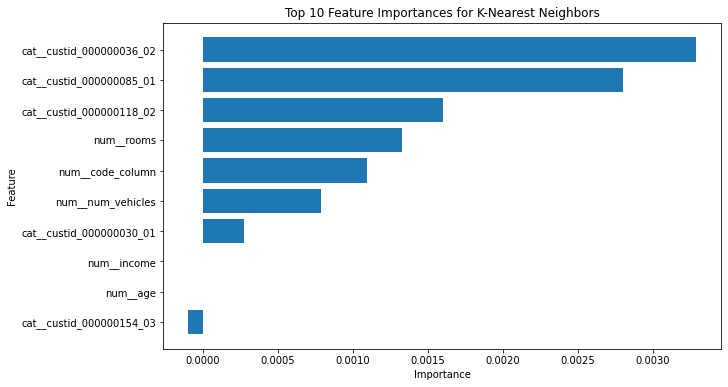


Top Features for Support Vector Machine:


,Feature,Importance
10,cat__custid_000000154_03,0.000524
8,cat__custid_000000085_01,0.000428
7,cat__custid_000000036_02,0.000400
1,num__num_vehicles,0.000345
9,cat__custid_000000118_02,0.000221
3,num__code_column,0.000152
6,cat__custid_000000030_01,0.000138
5,cat__custid_000000025_02,0.000124
11,cat__custid_000000163_02,0.000069
12,cat__custid_000000225_01,0.000028


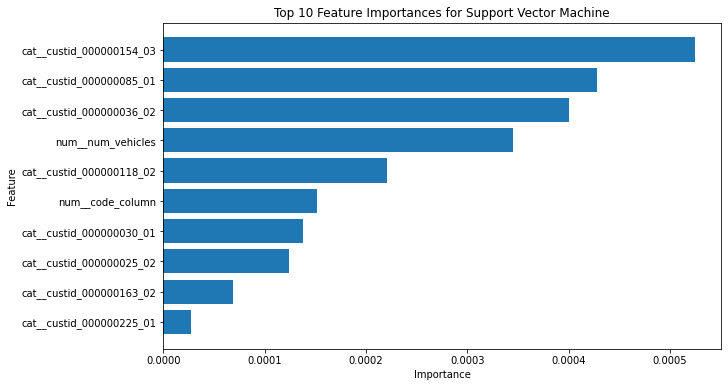

In [27]:
# Função para alinhar os nomes das features com as importâncias
def align_feature_names_with_importances(importances, feature_names):
    if len(importances) == len(feature_names):
        return feature_names
    elif len(importances) < len(feature_names):
        # Reduzir feature_names para o tamanho de importances
        return feature_names[:len(importances)]
    else:
        raise ValueError("Número de importâncias excede o número de nomes das features.")

# Função principal ajustada
for model_name, model in models.items():
    print(f"--- {model_name} ---")
    
    # Recalculando pipeline com modelo já treinado
    clf = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
    clf.fit(X_train, y_train)
    
    # Obter os nomes das features processadas
    processed_feature_names = get_feature_names(clf, X_train.columns)
    
    # Determinar importância das features
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_[0])
    
    else:
        perm_importance = permutation_importance(
            clf, X_test, y_test, scoring="accuracy"
        )
        importances = perm_importance.importances_mean

    # Alinhar nomes das features e importâncias
    aligned_feature_names = align_feature_names_with_importances(importances, processed_feature_names)
    
    # Consolidar os resultados em um DataFrame
    feature_importance_summary[model_name] = pd.DataFrame({
        "Feature": aligned_feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

# Exibir e visualizar as features mais importantes
for model_name, importance_df in feature_importance_summary.items():
    print(f"\nTop Features for {model_name}:")
    display(importance_df.head(10))  # Exibir as 10 principais features

    # Plotar as importâncias
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df["Feature"][:10], importance_df["Importance"][:10])
    plt.gca().invert_yaxis()
    plt.title(f"Top 10 Feature Importances for {model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()
